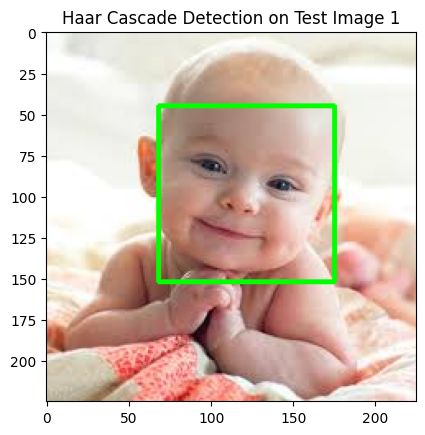

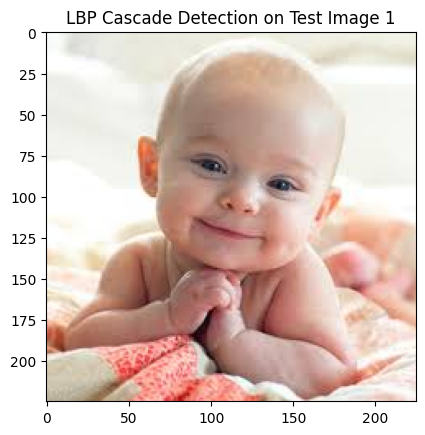

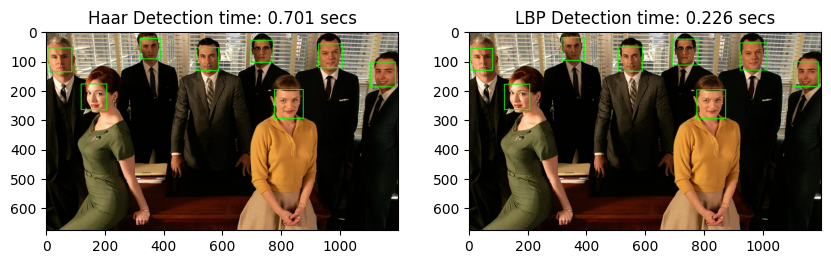

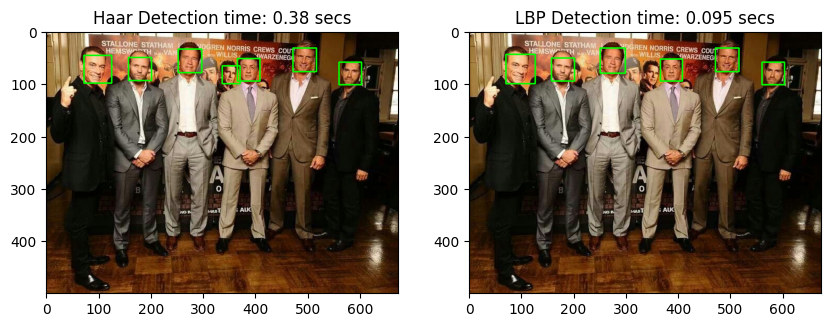

In [ ]:
# Import required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from google.colab import files

"""# Function to upload files to Colab
uploaded = files.upload()

# When you load an image using OpenCV, it loads that image into BGR color space by default.
# To show the colored image using `matplotlib`, we have to convert it to RGB space."""

def convertToRGB(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load the Haar and LBP cascades (ensure that you've uploaded these files)
haar_face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_alt.xml')
lbp_face_cascade = cv2.CascadeClassifier('/content/lbpcascade_frontalface.xml')

# Function to detect faces
def detect_faces(f_cascade, colored_img, scaleFactor=1.1):
    img_copy = np.copy(colored_img)
    # Convert the test image to gray image as opencv face detector expects gray images
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

    # Let's detect multiscale (some images may be closer to camera than others)
    faces = f_cascade.detectMultiScale(gray, scaleFactor=scaleFactor, minNeighbors=5)

    # Go over the list of faces and draw them as rectangles on original colored img
    for (x, y, w, h) in faces:
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return img_copy

# Load test images (ensure that you've uploaded images)
test1 = cv2.imread('/content/test1.jpg')
test2 = cv2.imread('/content/test2.jpg')
test3 = cv2.imread('/content/test3.jpg')
test4 = cv2.imread('/content/test4.jpg')

# Try the function on test images
faces_detected_img = detect_faces(haar_face_cascade, test1)
plt.imshow(convertToRGB(faces_detected_img))
plt.title('Haar Cascade Detection on Test Image 1')
plt.show()

faces_detected_img = detect_faces(lbp_face_cascade, test1)
plt.imshow(convertToRGB(faces_detected_img))
plt.title('LBP Cascade Detection on Test Image 1')
plt.show()

# Test-1: Compare performance of Haar vs LBP
# Load test images
test5 = cv2.imread('/content/test5.jpg')
test6 = cv2.imread('/content/test6.jpg')

# Test-1 - Haar vs LBP
t1 = time.time()
haar_detected_img = detect_faces(haar_face_cascade, test5)
t2 = time.time()
dt1 = t2 - t1

t1 = time.time()
lbp_detected_img = detect_faces(lbp_face_cascade, test5)
t2 = time.time()
dt2 = t2 - t1

# Display results
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.set_title('Haar Detection time: ' + str(round(dt1, 3)) + ' secs')
ax1.imshow(convertToRGB(haar_detected_img))

ax2.set_title('LBP Detection time: ' + str(round(dt2, 3)) + ' secs')
ax2.imshow(convertToRGB(lbp_detected_img))

plt.show()

# Test-2 - Haar vs LBP (on another image)
t1 = time.time()
haar_detected_img = detect_faces(haar_face_cascade, test6)
t2 = time.time()
dt1 = t2 - t1

t1 = time.time()
lbp_detected_img = detect_faces(lbp_face_cascade, test6)
t2 = time.time()
dt2 = t2 - t1

# Display results
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.set_title('Haar Detection time: ' + str(round(dt1, 3)) + ' secs')
ax1.imshow(convertToRGB(haar_detected_img))

ax2.set_title('LBP Detection time: ' + str(round(dt2, 3)) + ' secs')
ax2.imshow(convertToRGB(lbp_detected_img))

plt.show()